# Projeto M1 – Operações Pontuais e Filtragem Espacial

## Fluxo do Processamento

1. Seleção das imagens: escolher três radiografias de uma mesma região anatômica do conjunto
MURA e justificar a seleção.
2. Caracterização inicial: apresentar as imagens originais e identificar seus principais problemas
de qualidade.
3. Inserção de ruído: adicionar ruído controlado às imagens e registrar os parâmetros utilizados.
4. Operação pontual: aplicar uma técnica de transformação de intensidade escolhida pelo grupo.
5. Suavização: reduzir o ruído utilizando uma técnica de filtragem espacial.
6. Aguçamento: realçar detalhes ou estruturas utilizando uma técnica espacial adequada.
7. Segunda configuração: modificar uma técnica, parâmetro ou ordem do pipeline e repetir o
processamento.
8. Análise por métricas: selecionar duas métricas dentre as apresentadas em aula e utilizá-las
para comparar as imagens original, degradada e processadas. A escolha das métricas deverá
ser justificada.
9. Discussão: identificar qual configuração apresentou o melhor resultado para cada imagem e
discutir situações em que uma técnica apresentou comportamento inadequado

### Importações gerais

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure, metrics
from google.colab.patches import cv2_imshow

### Inserção de ruído

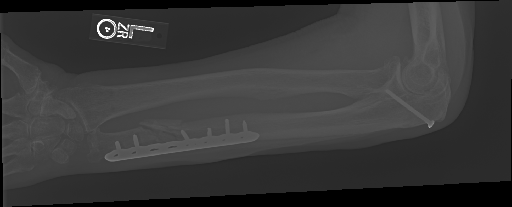

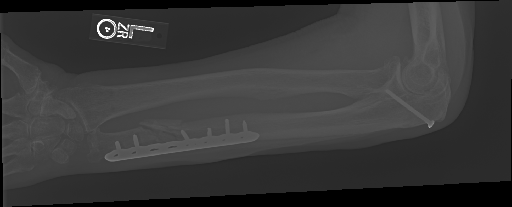

In [ ]:
img = cv2.imread('image1.png',0)

#cv2.setRNGSeed(999) #utilizar seed facilita o registro de comparações e testes
# noise = np.zeros(img.shape, np.uint8)
# cv2.randu(noise, 0, 12) # 0 até 12 deixa a imagem somente mais clara quando adiciona
# noisy_img = cv2.add(img, noise)
def add_noise(img, min = 0, max = 1):
    np.random.seed(999)
    noise = np.random.randint(min, max, img.shape).astype(np.int16) # valores aleatórios de -6 até 6
    noisy_img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8) # mantém valores dentro de 0 e 255
    return noisy_img

noisy_img = add_noise(img)

cv2_imshow(img)
cv2_imshow(noisy_img)

### Operação pontual: transformação de intensidade

Equalização de histograma

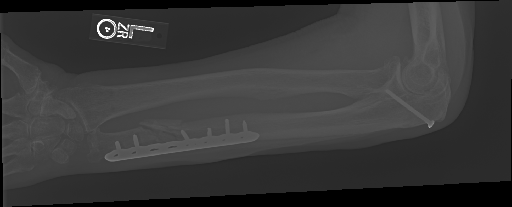

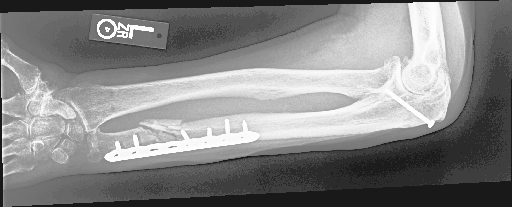

In [ ]:
def histogramaNormalizado(im):
  histogram = np.zeros(256)

  for i in range(im.shape[0]):
    for j in range(im.shape[1]):
      histogram[im[i, j]] += 1

  return histogram/(im.shape[0]*im.shape[1])

def histogramaAcumulado(histogram):
  acumulados = np.zeros(256)
  soma = 0

  for k in range(256):
    soma += histogram[k]
    acumulados[k] = soma

  return acumulados

def histEqualization(im):
  img = im.copy()

  histogram = histogramaNormalizado(img)
  acumulados = histogramaAcumulado(histogram)

  for i in range(img.shape[0]):
    for j in range(img.shape[1]):
      img[i,j] = round(acumulados[img[i,j]]*255)

  return img

img_equalizada = histEqualization(img)

cv2_imshow(img)
cv2_imshow(img_equalizada)

###Suavização (Implementações de Filtros de Média, Mediana, Gaussiano e Bilateral)
Essa parte foi iniciada puxando os códigos dos filtros de média e mediana utilizados no trabalho anterior.<br>
Então eu fiz a implementação dos filtros Gaussiano e Bilateral, para poder comparar resultados, principalmente porque eu achei que os resultados para remoção/redução de ruído dos filtros de média e mediana seriam insatisfatórios.<br>

Resumo simplificado sobre os filtros:<br>
**Média**: Soma os valores de todos os pixels dentro do kernel, então divide pelo número de pixels no kernel para conseguir uma média, que é aplicada no pixel central do kernel, que está no resultado final da suavização.<br>
**Mediana**: Pega os valores de todos os pixels dentro do kernel, e então seleciona o valor intermediário, que é então aplicado no pixel central do kernel, que está no resultado final da suavização(Boa para redução de ruído Salt and Pepper, que não é o ruído que adicionamos).<br>
**Gaussiano**: Similar ao filtro de média, mas cada pixel tem um peso/influência
diferente, com pixels mais próximos ao pixel central tendo mais peso, e pixels mais afastados, menos peso. Os pesos seguem uma distribuição Gaussiana.<br>
**Bilateral**: É os filtro com mais parâmetros desses que implementamos, que considera a distância de um pixel do pixel central e também a diferença de intensidade/cor para o pixel central. Pixels próximos e com valores semelhantes recebem maior peso, enquanto pixels próximos com uma grande diferença de intensidade, recebem pouco peso. Isso geralmente consegue reduzir ruído e preservar bordas. O que seria bem interessante para uso nessas imagens de raioX.

Função de filtro de média e função assitente de padding por replicação.

In [ ]:
def padding_replicacaoBW(imagem, k):
    """
    imagem deve ser BW
    Adiciona padding por replicação nas bordas da imagem.
    O tamanho do padding é definido por:
        r = (k - 1) / 2
    """
    altura, largura = imagem.shape
    r = k // 2

    # Cria uma nova imagem com espaço para o padding
    imagem_padding = np.zeros(
        (altura + 2 * r, largura + 2 * r),
        dtype=imagem.dtype
    )

    # o imagem original fica no centro
    for i in range(altura):
        for j in range(largura):
            imagem_padding[i + r, j + r] = imagem[i, j]


    for j in range(largura):
        for p in range(r): # Linha superior
            imagem_padding[p, j + r] = imagem[0, j]
        for p in range(r): # Linha inferior
            imagem_padding[altura + r + p, j + r] = imagem[altura - 1, j]

    for i in range(altura + 2 * r):
        for p in range(r): # Coluna esquerda
            imagem_padding[i, p] = imagem_padding[i, r]
        for p in range(r): # Coluna direita
            imagem_padding[i, largura + r + p] = imagem_padding[i, largura + r - 1]

    return imagem_padding


def filtro_mediaBW(imagem, k):
    """Aplica um filtro de média(box blur) na imagem, com kernel de tamanho k*k,
    e padding(tamanho = (k - 1) / 2) por replicação, onde k é um número ímpar e k>1."""
    altura, largura = imagem.shape
    imagem_padding = padding_replicacaoBW(imagem, k)

    imagem_filtrada = np.zeros((altura, largura), dtype=float)

    for i in range(altura):
        for j in range(largura):
            soma = 0.0

            # Percorre a máscara k x k
            for u in range(k):
                for v in range(k):
                    soma += float(imagem_padding[i + u, j + v])

            # Média dos k^2 pixels
            imagem_filtrada[i, j] = soma / (k * k)

    return imagem_filtrada

def filtro_media_otimizadoBW(imagem, k):
    """
    Aplica um filtro de média(box blur) na imagem, com kernel de tamanho k*k,
    e padding(tamanho = (k - 1) / 2) por replicação, onde k é um número ímpar e k>1.
    """
    altura, largura = imagem.shape
    r = k // 2
    imagem_padding = padding_replicacaoBW(imagem, k)
    altura_pad, largura_pad = imagem_padding.shape

    # Para cada linha do padding, calculamos a soma de cada janela horizontal de tamanho k.
    soma_horizontal = np.zeros((altura_pad, largura), dtype=float)

    for i in range(altura_pad):
        soma = 0.0

        for v in range(k):
            soma += float(imagem_padding[i, v])

        soma_horizontal[i, 0] = soma

        for j in range(1, largura):
            pixel_sai = float(imagem_padding[i, j - 1])
            pixel_entra = float(imagem_padding[i, j + k - 1])

            soma = soma - pixel_sai + pixel_entra
            soma_horizontal[i, j] = soma


    imagem_filtrada = np.zeros((altura, largura), dtype=float)

    for j in range(largura):
        # Primeira janela vertical
        soma = 0.0

        for u in range(k):
            soma += soma_horizontal[u, j]

        imagem_filtrada[0, j] = soma / (k * k)

        # Deslocamento vertical
        for i in range(1, altura):

            soma = (
                soma
                - soma_horizontal[i - 1, j]
                + soma_horizontal[i + k - 1, j]
            )

            imagem_filtrada[i, j] = soma / (k * k)

    imagem_filtrada = np.clip(imagem_filtrada, 0, 255).astype(np.uint8)
    return imagem_filtrada

Função de filtro de mediana e funções assitentes:

In [ ]:
def atualizar_lista(tons, quantidades, valor, delta):
    posicao = 0
    while posicao < len(tons) and tons[posicao] < valor:
        posicao += 1

    # O valor já existe
    if posicao < len(tons) and tons[posicao] == valor:
        quantidades[posicao] += delta
        # Se a quantidade chegou a zero, remove o tom das duas listas
        if quantidades[posicao] == 0:
            tons.pop(posicao)
            quantidades.pop(posicao)

    # O valor ainda não existe
    else:
        tons.insert(posicao, valor)
        quantidades.insert(posicao, delta)


def encontrar_mediana_lista(tons, quantidades, quantidade_total):
    """
    Encontra a mediana usando os tons ordenados e suas respectivas quantidades.
    """
    posicao_mediana = quantidade_total // 2
    acumulado = 0

    for i in range(len(tons)):
        acumulado += quantidades[i]
        if acumulado > posicao_mediana:
            return tons[i]

def filtro_mediana_otimizadoBW(imagem, k):
    """
    Aplica um filtro de mediana(median blur) na imagem, com kernel de tamanho k*k,
    e padding(tamanho = (k - 1) / 2) por replicação, onde k é um número ímpar e k>1.
    """
    altura, largura = imagem.shape
    imagem_padding = padding_replicacaoBW(imagem, k)
    imagem_filtrada = np.zeros((altura, largura), dtype=float )

    for i in range(altura):
        tons = [] # Lista ordenada dos tons presentes
        quantidades = []

        for u in range(k):
            for v in range(k):
                valor = int(imagem_padding[i + u, v])
                atualizar_lista(tons, quantidades, valor, +1)

        imagem_filtrada[i, 0] = encontrar_mediana_lista(tons, quantidades, k * k)

        for j in range(1, largura):
            coluna_sai = j - 1
            for u in range(k):
                valor = int(imagem_padding[i + u, coluna_sai])
                atualizar_lista(tons, quantidades, valor, -1)


            coluna_entra = j + k - 1
            for u in range(k):
                valor = int(imagem_padding[i + u, coluna_entra])
                atualizar_lista(tons, quantidades, valor, +1)

            # Calcula a nova mediana
            imagem_filtrada[i, j] = encontrar_mediana_lista(tons, quantidades, k * k)

    imagem_filtrada = np.clip(imagem_filtrada, 0, 255).astype(np.uint8)
    return imagem_filtrada

Filtro Gaussiano e assistente:

In [ ]:
def kernel_gaussiano_1D(k, sigma):
    """
    Gera um kernel Gaussiano 1D de tamanho k.
    k deve ser ímpar e > 1.
    sigma controla a intensidade da suavização.
    """
    if k <= 1 or k % 2 == 0:
        raise ValueError("k deve ser um número ímpar e maior que 1.")

    if sigma <= 0:
        raise ValueError("sigma deve ser maior que 0.")

    r = k // 2
    kernel = np.zeros(k, dtype=float)

    for i in range(k):
        x = i - r
        kernel[i] = np.exp(-(x ** 2) / (2 * sigma ** 2))

    # Normalização: a soma dos pesos deve ser 1
    kernel /= kernel.sum()
    return kernel

def filtro_gaussianoBW(imagem, k, sigma):
    """
    Aplica um filtro Gaussiano separável em uma imagem BW.
    k, tamanho do kernel (ímpar e > 1)
    sigma, desvio padrão da distribuição Gaussiana

    O padding é feito por replicação.
    """

    altura, largura = imagem.shape
    r = k // 2
    kernel = kernel_gaussiano_1D(k, sigma)
    imagem_padding = padding_replicacaoBW(imagem, k)
    altura_pad, largura_pad = imagem_padding.shape

    imagem_horizontal = np.zeros((altura, largura), dtype=float)

    for i in range(altura):
        for j in range(largura):
            soma = 0.0
            for v in range(k):
                soma += (float(imagem_padding[i + r, j + v]) * kernel[v])
            imagem_horizontal[i, j] = soma

    # Fazemos padding novamente na imagem intermediária
    imagem_horizontal_padding = padding_replicacaoBW(imagem_horizontal, k)
    imagem_filtrada = np.zeros((altura, largura), dtype=float)

    for j in range(largura):
        for i in range(altura):
            soma = 0.0
            for u in range(k):
                soma += (float(imagem_horizontal_padding[i + u, j + r]) * kernel[u])
            imagem_filtrada[i, j] = soma
    imagem_filtrada = np.clip(imagem_filtrada, 0, 255).astype(np.uint8)
    return imagem_filtrada

Filtro Bilateral:

In [ ]:
def filtro_bilateralBW(imagem, k, sigma_espacial, sigma_intensidade):
    """
    Aplica um filtro bilateral em uma imagem BW.
    k , tamanho da janela, ímpar e > 1
    sigma_espacial, controla a influência da distância espacial(usar valores baseado no tamanho do kernel(k//2 como valor máximo efetivo))
    sigma_intensidade, controla a influência da diferença de intensidade
    (usar valores baseados na variação do ruído(-12 <-> 12) que estamos introduzindo para teste com variação de 1 até 25),
    O padding é feito por replicação.
    """
    if k <= 1 or k % 2 == 0:
        raise ValueError("k deve ser ímpar e maior que 1.")

    if sigma_espacial <= 0:
        raise ValueError("sigma_espacial deve ser maior que 0.")

    if sigma_intensidade <= 0:
        raise ValueError("sigma_intensidade deve ser maior que 0.")

    altura, largura = imagem.shape
    r = k // 2
    imagem_padding = padding_replicacaoBW(imagem, k)
    imagem_filtrada = np.zeros((altura, largura), dtype=float)

    pesos_espaciais = np.zeros((k, k), dtype=float)
    for u in range(k):
        for v in range(k):
            dy = u - r
            dx = v - r
            distancia_quadrada = (dx ** 2 + dy ** 2)
            pesos_espaciais[u, v] = np.exp(-distancia_quadrada / (2 * sigma_espacial ** 2))

    pesos_intensidade = np.zeros(256, dtype=float)
    for d in range(256):
        pesos_intensidade[d] = np.exp(-(d ** 2) /(2 * sigma_intensidade ** 2))

    for i in range(altura):
        for j in range(largura):
            pixel_central = int(imagem_padding[i + r, j + r])
            soma_ponderada = 0.0
            soma_pesos = 0.0

            for u in range(k):
                for v in range(k):
                    pixel_vizinho = int(imagem_padding[i + u, j + v])
                    diferenca = abs(pixel_vizinho - pixel_central)
                    peso_espacial = pesos_espaciais[u, v]
                    peso_intensidade = pesos_intensidade[diferenca]
                    peso = (peso_espacial *peso_intensidade)
                    soma_ponderada += (pixel_vizinho * peso)
                    soma_pesos += peso

            imagem_filtrada[i, j] = (
                soma_ponderada / soma_pesos
            )

    imagem_filtrada = np.clip(imagem_filtrada, 0, 255).astype(np.uint8)
    return imagem_filtrada


Testes de funções de suavização: Box blur, Median blur, Gaussian blur e Bilateral blur.

Valores com tamanho kernel acima de 5/7 com Box blur acabam destruindo muito os detalhes da imagem.
Considerar passar Box blur várias vezes com kernel pequeno(3) para pequenos ajustes de suavização.

In [ ]:
img_suavizada = filtro_media_otimizadoBW(img_equalizada, 5)

# cv2_imshow(noisy_img)
# cv2_imshow(img_equalizada)

# cv2_imshow(img_suavizada)

# cv2_imshow(filtro_media_otimizadoBW(noisy_img, 3))
# cv2_imshow(filtro_media_otimizadoBW(filtro_media_otimizadoBW(noisy_img, 3),3))
# cv2_imshow(filtro_media_otimizadoBW(noisy_img, 5))
# cv2_imshow(filtro_media_otimizadoBW(noisy_img, 7))
# cv2_imshow(filtro_media_otimizadoBW(noisy_img, 9))
# cv2_imshow(filtro_media_otimizadoBW(noisy_img, 11))

# cv2_imshow(filtro_mediana_otimizadoBW(noisy_img, 3))
# cv2_imshow(filtro_mediana_otimizadoBW(noisy_img, 5))
# cv2_imshow(filtro_mediana_otimizadoBW(noisy_img, 7))
# cv2_imshow(filtro_mediana_otimizadoBW(noisy_img, 9))
# cv2_imshow(filtro_mediana_otimizadoBW(noisy_img, 11))
# cv2_imshow(filtro_media_otimizadoBW(filtro_mediana_otimizadoBW(noisy_img, 3),3))

# cv2_imshow(filtro_gaussianoBW(noisy_img, 3, .5))
# cv2_imshow(filtro_gaussianoBW(noisy_img, 3, 1))
# cv2_imshow(filtro_gaussianoBW(noisy_img, 5, .5))
# cv2_imshow(filtro_gaussianoBW(noisy_img, 5, 1))
# cv2_imshow(filtro_gaussianoBW(noisy_img, 5, 2))
# cv2_imshow(filtro_gaussianoBW(noisy_img, 7, .5))
# cv2_imshow(filtro_gaussianoBW(noisy_img, 7, 1))
# cv2_imshow(filtro_gaussianoBW(noisy_img, 7, 2))
# cv2_imshow(filtro_gaussianoBW(noisy_img, 9, 1))

# cv2_imshow(filtro_bilateralBW(noisy_img, 3, 1, 12))
# cv2_imshow(filtro_bilateralBW(noisy_img, 3, 1, 25))
# cv2_imshow(filtro_bilateralBW(noisy_img, 3, 1, 40))
# cv2_imshow(filtro_bilateralBW(noisy_img, 5, 2, 12))
# cv2_imshow(filtro_bilateralBW(noisy_img, 5, 2, 25))
# cv2_imshow(filtro_bilateralBW(noisy_img, 5, 2, 40))
# cv2_imshow(filtro_bilateralBW(noisy_img, 7, 1, 12))
# cv2_imshow(filtro_bilateralBW(noisy_img, 7, 2, 12))
# cv2_imshow(filtro_bilateralBW(noisy_img, 7, 3, 12))

### Testes das Suavizações com Métricas de qualidade
escolher 2 dentre MSE, RMSE, PSNR, SSIM e GMSD, para utilizarmos no pipeline final

MSE:
utilizada para identificar
distorções espaciais (estruturas - simetria) da
imagem após processamento
– Quanto mais próximo do zero, mais iguais as imagens são

RMSE:
Erro padronizado, mais utilizado que MSE. maior é pior.

PSNR:
É a razão entre a potência máxima de um sinal e a potência máxima do sinal do ruído:
– Medido em dB
– Quanto maior melhor (considerável bom >= 20 dB)
• Boa para avaliar filtros de suavização

SSIM:
métrica baseada em recurso do Sistema Visual Humano (HVS) – Hue, Saturation or Intensity Value.
– O SSIM mede a semelhança entre duas imagens, sendo
uma melhoria em relação a métodos como MSE e PSNR
• Basicamente, calcula a degradação da imagem
para algum processo.
– Vai de -1 a 1, sendo 1 para imagens idênticas

GMSD:
assim como SSIM, é uma métrica para o HSV
• Avalia a distorção causada pelo processamento
entre a imagem de referência e a imagem processada
– Quanto menor o valor melhor a resultado


In [ ]:
pip install sporco

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 55.6 MB/s eta 0:00:00


In [ ]:
import sporco.metric as sm

mse_val = metrics.mean_squared_error(img, noisy_img)

rmse_val = np.sqrt(mse_val)

psnr_val = metrics.peak_signal_noise_ratio(img, noisy_img, data_range=255)

ssim_val = metrics.structural_similarity(img, noisy_img, data_range=255, multichannel=True)

gmsd_val = sm.gmsd(img, noisy_img)

print("MSE(↓): ", mse_val)
print("RMSE(↓): ", rmse_val)
print("PSNR(maior melhor): ", psnr_val)
print("SSIM(-1<->1): ", ssim_val)
print("GMSD(↓): ", gmsd_val)
# cv2_imshow(img)
# cv2_imshow(noisy_img)

MSE(↓):  0.0
RMSE(↓):  0.0
PSNR(maior melhor):  inf
SSIM(-1<->1):  1.0
GMSD(↓):  0.0


/usr/local/lib/python3.13/dist-packages/skimage/metrics/simple_metrics.py:168: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)


Testes de Blurs com métricas

seed utilizada:999<br>Ruído aleatório de -6 até +6<br>Esses são os resultados comparando a imagem com ruído a imagem original:<br>
RMSE(↓):  3.650562409105997<br>
PSNR(maior melhor):  36.883608060067104<br>
SSIM(-1<->1):  0.8349767405074123<br>
GMSD(↓):  0.017615737612245153<br>

Então usamos estás métricas, dando foco principal em RMSE e PSNR, e importância menor a SSIM, para comparar todos os filtros com parâmetros diferentes, e então verificar qual é o melhor filtro de suavização para redução de ruído em nossas imagens.

**Análise geral:**<br>
Na métrica **SSIM**, todos os filtros apresentaram resultados melhores que a imagem com ruído, porém, em **GMSD**, média e mediana falharam todos os testes, o filtro_gaussiano obteve resultados positivos com kernel 3 e 5, e um sigma de 0.5(que é um valor bem baixo, mantendo a imagem basicamente igual e reduzindo apenas ruído muito fino), enquanto o Bilateral obteve resultados positivos com a maioria dos parâmetros testados(só falhando com k>7 && sigmas elevados).

Com **RMSE**, os filtros tendem a ter resultados piores com kernels maiores. Comparando entre si, o Filtro bilateral obteve os melhores resultados(sem nenhum resultado negativo), seguido, do Gaussiano(com somente 2 resultados positivos, mas novamente com sigma 0.5, e sendo que todos os resultados de bilateral), Mediana obteve resultados melhores que a média, mas os dois filtros só obteram resultados negativos.<br>
Em **PSNR**, as mesmas características encontradas em RMSE se repetem. Bilateral só obteve resultados positivos, Gaussiano só obteve resultados positivos com sigma muito baixo, enquanto média e mediana,  só obteram resultados negativos.

Tabelas para comparações de filtros de suavização com métricas:

|index|Filtro|k|Repeticoes|RMSE\(↓, &lt; 3\.650562\)|PSNR\(&gt;36\.883608\)|SSIM\(-1&lt;-&gt;1, &gt; 0\.834976\)|GMSD\(↓, &lt; 0\.017615\)|
|---|---|---|---|---|---|---|---|
|0|Box|3|1|5\.709795|32\.998393|0\.934968|0\.041518|
|1|Box|3|2|6\.267156|32\.189394|0\.935808|0\.060687|
|2|Box|3|3|6\.949806|31\.29135|0\.927003|0\.073802|
|3|Box|5|1|7\.568132|30\.55103|0\.916446|0\.085|
|4|Box|5|2|8\.007706|30\.060641|0\.905165|0\.101494|
|5|Box|7|1|8\.554201|29\.487215|0\.892415|0\.112901|
|6|Box|7|2|8\.984249|29\.061168|0\.87887|0\.124825|
|7|Box|9|1|9\.219006|28\.837121|0\.870701|0\.135846|
|8|Mediana|3|1|4\.368079|35\.324994|0\.936902|0\.0222|
|9|Mediana|3|2|4\.747144|34\.602156|0\.953457|0\.025201|
|10|Mediana|3|3|5\.023595|34\.110511|0\.95741|0\.028259|
|11|Mediana|5|1|6\.836366|31\.434298|0\.94935|0\.039993|
|12|Mediana|5|2|7\.469031|30\.665519|0\.953469|0\.054532|
|13|Mediana|7|1|8\.540611|29\.501025|0\.942855|0\.068044|
|14|Mediana|7|2|8\.742329|29\.298261|0\.943439|0\.080177|
|15|Mediana|9|1|9\.01843|29\.028185|0\.934027|0\.082246|

|index|Filtro|k|sigma|Repeticoes|RMSE\(↓, &lt; 3\.650562\)|PSNR\(&gt;36\.883608\)|SSIM\(-1&lt;-&gt;1, &gt; 0\.834976\)|GMSD\(↓, &lt; 0\.017615\)|
|---|---|---|---|---|---|---|---|---|
|0|Gaussian|3|0\.5|1|3\.163846|38\.126496|0\.91308|0\.015301|
|1|Gaussian|3|0\.5|2|3\.79926|36\.536824|0\.937141|0\.020895|
|2|Gaussian|3|0\.5|3|4\.47244|35\.119913|0\.943504|0\.029421|
|3|Gaussian|3|0\.5|4|5\.024209|34\.109451|0\.943938|0\.037731|
|4|Gaussian|3|0\.7|1|4\.118157|35\.836746|0\.940598|0\.023176|
|5|Gaussian|3|0\.7|2|5\.287703|33\.665463|0\.942796|0\.041096|
|6|Gaussian|3|0\.85|1|4\.628703|34\.821618|0\.942228|0\.02859|
|7|Gaussian|3|0\.85|2|5\.708991|32\.999617|0\.940469|0\.048382|
|8|Gaussian|3|1\.0|1|4\.938017|34\.259753|0\.941437|0\.032134|
|9|Gaussian|3|1\.5|1|5\.377342|33\.519451|0\.938483|0\.037412|
|10|Gaussian|3|2\.0|1|5\.525441|33\.283465|0\.937048|0\.039235|
|11|Gaussian|5|0\.5|1|3\.165206|38\.122763|0\.913191|0\.015311|
|12|Gaussian|5|1\.0|1|5\.46656|33\.376521|0\.941989|0\.044168|
|13|Gaussian|7|0\.5|1|3\.165206|38\.122763|0\.913191|0\.015311|
|14|Gaussian|7|1\.0|1|5\.508094|33\.310776|0\.941775|0\.044879|

|index|Filtro|k|sigma\_espacial|sigma\_intensidade|Repeticoes|RMSE\(↓, &lt; 3\.650562\)|PSNR\(&gt;36\.883608\)|SSIM\(-1&lt;-&gt;1, &gt; 0\.834976\)|GMSD\(↓, &lt; 0\.017615\)|
|---|---|---|---|---|---|---|---|---|---|
|0|Bilateral|3|0\.8|5|1|2\.521277|40\.098391|0\.911105|0\.014038|
|1|Bilateral|3|1\.0|10|1|1\.76762|43\.183024|0\.952|0\.011041|
|2|Bilateral|3|1\.5|10|1|1\.700622|43\.518647|0\.9554|0\.010648|
|3|Bilateral|3|1\.5|15|1|1\.679974|43\.624753|0\.957472|0\.010167|
|4|Bilateral|3|2\.0|20|1|1\.769959|43\.171541|0\.956423|0\.010185|
|5|Bilateral|5|1\.0|5|1|2\.269679|41\.011514|0\.926199|0\.012316|
|6|Bilateral|5|1\.5|10|1|1\.517572|44\.507819|0\.964051|0\.00868|
|7|Bilateral|5|2\.0|10|1|1\.510487|44\.548466|0\.964746|0\.00879|
|8|Bilateral|5|2\.0|15|1|1\.588689|44\.110026|0\.963901|0\.010328|
|9|Bilateral|5|2\.5|20|1|1\.796826|43\.040685|0\.959648|0\.012994|
|10|Bilateral|5|2\.5|25|1|2\.043946|41\.921414|0\.95551|0\.01677|
|11|Bilateral|7|1\.5|10|1|1\.497716|44\.622213|0\.965088|0\.008672|
|12|Bilateral|7|2\.0|15|1|1\.632043|43\.876171|0\.963184|0\.013558|
|13|Bilateral|7|2\.5|20|1|1\.920118|42\.464247|0\.956135|0\.02005|
|14|Bilateral|7|3\.0|25|1|2\.278588|40\.977488|0\.948266|0\.027993|

In [ ]:
import pandas as pd

def calcular_metricas(ref, test):
    mse = metrics.mean_squared_error(ref, test)
    rmse = np.sqrt(mse)

    psnr = metrics.peak_signal_noise_ratio( ref, test, data_range=255 )

    ssim = metrics.structural_similarity( ref, test, data_range=255 )

    gmsd = sm.gmsd( ref, test, rescale=True, returnMap=False )

    return {
        # "MSE(↓)": mse,
        "RMSE(↓, < 3.650562)": rmse,
        "PSNR(>36.883608)": psnr,
        "SSIM(-1<->1, > 0.834976)": ssim,
        "GMSD(↓, < 0.017615)": gmsd
    }

def avaliar_filtro(nome, filtro, ref, noisy, repeticoes=1, **parametros):
    resultado = noisy

    for _ in range(repeticoes):
        resultado = filtro( resultado, **parametros )

    cv2_imshow(resultado)
    metricas = calcular_metricas( ref, resultado )

    registro = {
        "Filtro": nome,
        **parametros,
        "Repeticoes": repeticoes,
        **metricas
    }

    return registro, resultado


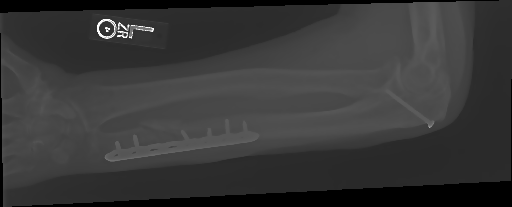

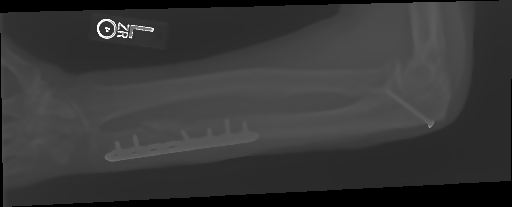

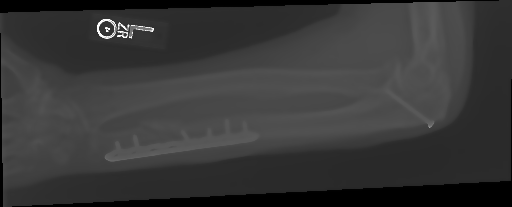

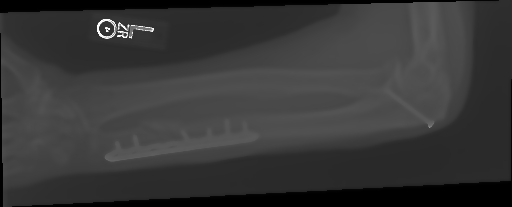

,Filtro,k,sigma_espacial,sigma_intensidade,Repeticoes,"RMSE(↓, < 3.650562)",PSNR(>36.883608),"SSIM(-1<->1, > 0.834976)","GMSD(↓, < 0.017615)"
0,Bilateral,7,1.5,10,1,1.175790,46.724208,0.986810,0.006060
1,Bilateral,7,2.0,15,1,1.526147,44.458875,0.978548,0.013399
2,Bilateral,7,2.5,20,1,1.819784,42.930408,0.971462,0.020643
3,Bilateral,7,3.0,25,1,2.143193,41.509576,0.964210,0.027635


In [ ]:
experimentos = [
    # {
    #     "nome": "Box",
    #     "filtro": filtro_mediaBW,
    #     "parametros": {"k": 3}
    # },
    # {
    #     "nome": "Box",
    #     "filtro": filtro_mediaBW,
    #     "parametros": {"k": 3},
    #     "repeticoes": 2
    # },
    # {
    #     "nome": "Box",
    #     "filtro": filtro_mediaBW,
    #     "parametros": {"k": 3},
    #     "repeticoes": 3
    # },
    # {
    #     "nome": "Box",
    #     "filtro": filtro_mediaBW,
    #     "parametros": {"k": 5}
    # },
    # {
    #     "nome": "Box",
    #     "filtro": filtro_mediaBW,
    #     "parametros": {"k": 5},
    #     "repeticoes": 2
    # },
    # {
    #     "nome": "Box",
    #     "filtro": filtro_mediaBW,
    #     "parametros": {"k": 7}
    # },
    # {
    #     "nome": "Box",
    #     "filtro": filtro_mediaBW,
    #     "parametros": {"k": 7},
    #     "repeticoes": 2
    # },
    # {
    #     "nome": "Box",
    #     "filtro": filtro_mediaBW,
    #     "parametros": {"k": 9}
    # },


    # {
    #     "nome": "Mediana",
    #     "filtro": filtro_mediana_otimizadoBW,
    #     "parametros": {"k": 3}
    # },
    # {
    #     "nome": "Mediana",
    #     "filtro": filtro_mediana_otimizadoBW,
    #     "parametros": {"k": 3},
    #     "repeticoes": 2
    # },
    # {
    #     "nome": "Mediana",
    #     "filtro": filtro_mediana_otimizadoBW,
    #     "parametros": {"k": 3},
    #     "repeticoes": 3
    # },
    # {
    #     "nome": "Mediana",
    #     "filtro": filtro_mediana_otimizadoBW,
    #     "parametros": {"k": 5}
    # },
    # {
    #     "nome": "Mediana",
    #     "filtro": filtro_mediana_otimizadoBW,
    #     "parametros": {"k": 5},
    #     "repeticoes": 2
    # },
    # {
    #     "nome": "Mediana",
    #     "filtro": filtro_mediana_otimizadoBW,
    #     "parametros": {"k": 7}
    # },
    # {
    #     "nome": "Mediana",
    #     "filtro": filtro_mediana_otimizadoBW,
    #     "parametros": {"k": 7},
    #     "repeticoes": 2
    # },
    # {
    #     "nome": "Mediana",
    #     "filtro": filtro_mediana_otimizadoBW,
    #     "parametros": {"k": 9}
    # },

    # {
    #     "nome": "Gaussian",
    #     "filtro": filtro_gaussianoBW,
    #     "parametros": {"k": 3, "sigma": 0.5}
    # },
    # {
    #     "nome": "Gaussian",
    #     "filtro": filtro_gaussianoBW,
    #     "parametros": {"k": 3, "sigma": 0.5},
    #     "repeticoes": 2
    # },
    # {
    #     "nome": "Gaussian",
    #     "filtro": filtro_gaussianoBW,
    #     "parametros": {"k": 3, "sigma": 0.5},
    #     "repeticoes": 3
    # },
    # {
    #     "nome": "Gaussian",
    #     "filtro": filtro_gaussianoBW,
    #     "parametros": {"k": 3, "sigma": 0.5},
    #     "repeticoes": 4
    # },

    # {
    #     "nome": "Gaussian",
    #     "filtro": filtro_gaussianoBW,
    #     "parametros": {"k": 3, "sigma": 0.7}
    # },
    # {
    #     "nome": "Gaussian",
    #     "filtro": filtro_gaussianoBW,
    #     "parametros": {"k": 3, "sigma": 0.7},
    #     "repeticoes": 2
    # },

    # {
    #     "nome": "Gaussian",
    #     "filtro": filtro_gaussianoBW,
    #     "parametros": {"k": 3, "sigma": 0.85}
    # },
    # {
    #     "nome": "Gaussian",
    #     "filtro": filtro_gaussianoBW,
    #     "parametros": {"k": 3, "sigma": 0.85},
    #     "repeticoes": 2
    # },

    # {
    #     "nome": "Gaussian",
    #     "filtro": filtro_gaussianoBW,
    #     "parametros": {"k": 3, "sigma": 1.0}
    # },
    # {
    #     "nome": "Gaussian",
    #     "filtro": filtro_gaussianoBW,
    #     "parametros": {"k": 3, "sigma": 1.5}
    # },
    # {
    #     "nome": "Gaussian",
    #     "filtro": filtro_gaussianoBW,
    #     "parametros": {"k": 3, "sigma": 2.0}
    # },

    # {
    #     "nome": "Gaussian",
    #     "filtro": filtro_gaussianoBW,
    #     "parametros": {"k": 5, "sigma": 0.5}
    # },
    # {
    #     "nome": "Gaussian",
    #     "filtro": filtro_gaussianoBW,
    #     "parametros": {"k": 5, "sigma": 1.0}
    # },

    # {
    #     "nome": "Gaussian",
    #     "filtro": filtro_gaussianoBW,
    #     "parametros": {"k": 7, "sigma": 0.5}
    # },
    # {
    #     "nome": "Gaussian",
    #     "filtro": filtro_gaussianoBW,
    #     "parametros": {"k": 7, "sigma": 1.0}
    # },


    # {
    #     "nome": "Bilateral",
    #     "filtro": filtro_bilateralBW,
    #     "parametros": {
    #         "k": 3,
    #         "sigma_espacial": 0.8,
    #         "sigma_intensidade": 5
    #     }
    # },
    # {
    #     "nome": "Bilateral",
    #     "filtro": filtro_bilateralBW,
    #     "parametros": {
    #         "k": 3,
    #         "sigma_espacial": 1.0,
    #         "sigma_intensidade": 10
    #     }
    # },
    # {
    #     "nome": "Bilateral",
    #     "filtro": filtro_bilateralBW,
    #     "parametros": {
    #         "k": 3,
    #         "sigma_espacial": 1.5,
    #         "sigma_intensidade": 10
    #     }
    # },
    # {
    #     "nome": "Bilateral",
    #     "filtro": filtro_bilateralBW,
    #     "parametros": {
    #         "k": 3,
    #         "sigma_espacial": 1.5,
    #         "sigma_intensidade": 15
    #     }
    # },
    # {
    #     "nome": "Bilateral",
    #     "filtro": filtro_bilateralBW,
    #     "parametros": {
    #         "k": 3,
    #         "sigma_espacial": 2.0,
    #         "sigma_intensidade": 20
    #     }
    # },

    # {
    #     "nome": "Bilateral",
    #     "filtro": filtro_bilateralBW,
    #     "parametros": {
    #         "k": 5,
    #         "sigma_espacial": 1.0,
    #         "sigma_intensidade": 5
    #     }
    # },
    # {
    #     "nome": "Bilateral",
    #     "filtro": filtro_bilateralBW,
    #     "parametros": {
    #         "k": 5,
    #         "sigma_espacial": 1.5,
    #         "sigma_intensidade": 10
    #     }
    # },
    # {
    #     "nome": "Bilateral",
    #     "filtro": filtro_bilateralBW,
    #     "parametros": {
    #         "k": 5,
    #         "sigma_espacial": 2.0,
    #         "sigma_intensidade": 10
    #     }
    # },
    # {
    #     "nome": "Bilateral",
    #     "filtro": filtro_bilateralBW,
    #     "parametros": {
    #         "k": 5,
    #         "sigma_espacial": 2.0,
    #         "sigma_intensidade": 15
    #     }
    # },
    # {
    #     "nome": "Bilateral",
    #     "filtro": filtro_bilateralBW,
    #     "parametros": {
    #         "k": 5,
    #         "sigma_espacial": 2.5,
    #         "sigma_intensidade": 20
    #     }
    # },
    # {
    #     "nome": "Bilateral",
    #     "filtro": filtro_bilateralBW,
    #     "parametros": {
    #         "k": 5,
    #         "sigma_espacial": 2.5,
    #         "sigma_intensidade": 25
    #     }
    # },

    {
        "nome": "Bilateral",
        "filtro": filtro_bilateralBW,
        "parametros": {
            "k": 7,
            "sigma_espacial": 1.5,
            "sigma_intensidade": 10
        }
    },
    {
        "nome": "Bilateral",
        "filtro": filtro_bilateralBW,
        "parametros": {
            "k": 7,
            "sigma_espacial": 2.0,
            "sigma_intensidade": 15
        }
    },
    {
        "nome": "Bilateral",
        "filtro": filtro_bilateralBW,
        "parametros": {
            "k": 7,
            "sigma_espacial": 2.5,
            "sigma_intensidade": 20
        }
    },
    {
        "nome": "Bilateral",
        "filtro": filtro_bilateralBW,
        "parametros": {
            "k": 7,
            "sigma_espacial": 3.0,
            "sigma_intensidade": 25
        }
    }
]

resultados = []
imagens_filtradas = {}

for experimento in experimentos:

    registro, resultado = avaliar_filtro(
        experimento["nome"],
        experimento["filtro"],
        img,
        noisy_img,
        repeticoes=experimento.get("repeticoes", 1),
        **experimento["parametros"]
    )

    resultados.append(registro)

    chave = len(resultados) - 1
    imagens_filtradas[chave] = resultado

df_resultados = pd.DataFrame(resultados).round(6)

df_resultados


### Suavização utilizada:

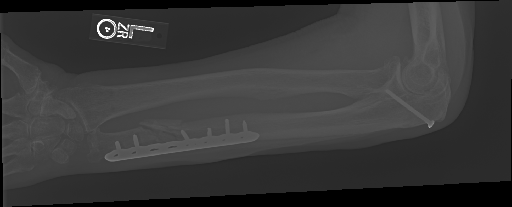

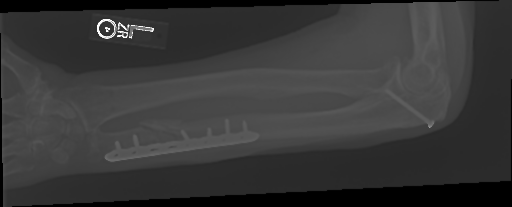

In [ ]:
img_suavizada = filtro_bilateralBW(noisy_img, 3, 1.5, 25)

cv2_imshow(noisy_img)
cv2_imshow(img_suavizada)
# cv2_imshow(filtro_bilateralBW(noisy_img, 7, 1.5, 10))

### Aguçamento
Unsharp masking

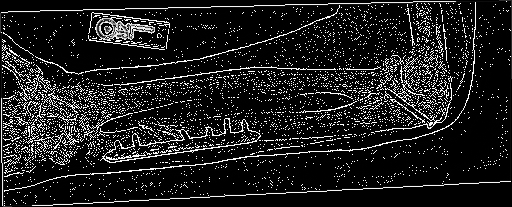

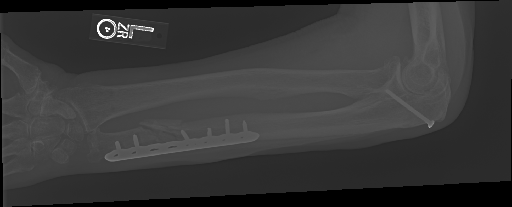

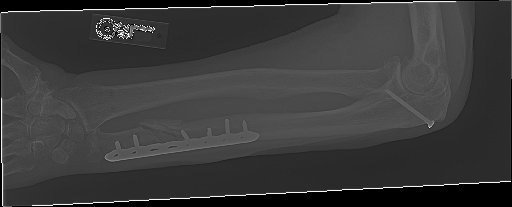

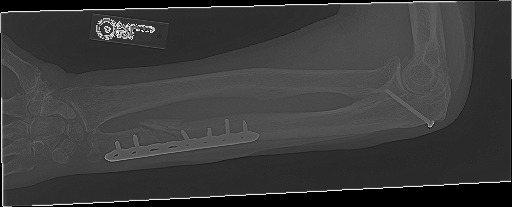

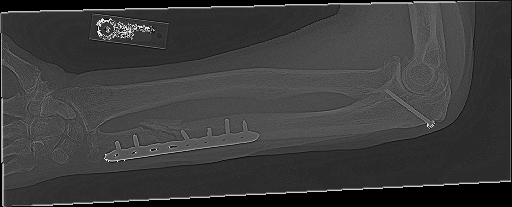

In [ ]:
def obterLaplaciano(img):
    original = img.astype(np.float64)
    laplaciano = np.zeros(img.shape, np.float64)

    for i in range(1, img.shape[0] - 1):
        for j in range(1, img.shape[1] - 1):
            laplaciano[i, j] = (
                original[i - 1, j] +
                original[i + 1, j] +
                original[i, j - 1] +
                original[i, j + 1] -
                4 * original[i, j]
            )

    return laplaciano

def obterLaplacianoBorrado(img):
  # Float permite fazer as somas sem overflow de uint8
  original = img.astype(np.float64)
  laplaciano = np.zeros(img.shape, np.uint8)

  # Nesta implementação, as bordas permanecem iguais às originais
  for i in range(1, img.shape[0] - 1):
    for j in range(1, img.shape[1] - 1):
      laplaciano[i, j] = (
        original[i - 1, j] +
        original[i + 1, j] +
        original[i, j - 1] +
        original[i, j + 1]
      )/4

  return laplaciano.astype(np.uint8)

# img = cv2.imread('image1.png',0)

img_laplaciano = obterLaplacianoBorrado(img)

mask = img - img_laplaciano

cv2_imshow(mask)

cv2_imshow(img)
cv2_imshow(img + mask*1)
cv2_imshow(img + mask*2)
cv2_imshow(img + mask*5)

img = img + mask*5

# print("------")

# img_laplaciano = obterLaplaciano(img)

# img_realcada = img - img_laplaciano*2

# cv2_imshow(img_realcada)

##Teste de Pipeline 1 (Equalização -> Suavização -> Sharpness)

Vamos focar nas Métricas PSNR, que ajuda a analisar a similaridade dos pixels e a redução de ruído, e SSIM, que foca na analise da estrutura das imagens

In [ ]:
def calcular_metricas(img_ref, img_tratada):
    # mse_val = metrics.mean_squared_error(img_ref, img_tratada)
    # rmse_val = np.sqrt(mse_val)
    psnr_val = metrics.peak_signal_noise_ratio(img_ref, img_tratada, data_range=255)
    ssim_val = metrics.structural_similarity(img_ref, img_tratada, data_range=255, multichannel=True)
    # gmsd_val = sm.gmsd(img_ref, img_tratada)

    return psnr_val, ssim_val

Nesse teste com a imagem5 foi utilizado um ruído de -25 até +25, com resultados:[Imagem5_ruido](https://drive.google.com/file/d/15WzQS2Ddfy49l5bmOzxWqFds4VKPovjz/view?usp=drive_link)<br>
PSNR: 24.96925431134551 <br>
SSIM: 0.34769829008371156<br>

[após a equalização](https://drive.google.com/file/d/1UUdcRFHKPzrVNaQlWjKdZQ82ueum1t1y/view?usp=drive_link) de histograma obtemos:<br>
PSNR: 13.572553973417367 <br>
SSIM: 0.14766343951841332<br>
que são resultados bem baixos, mas isso faz sentido pois a equalização acaba mudando a imagem e a deixa mais diferente da original, especialmente já que o histograma acaba intensificando o ruído presente na imagem.

Na [suavização](https://drive.google.com/file/d/1DPGRFc6_1nYuhu7sP_m_4DOrrFpm7cc6/view?usp=drive_link) decidimos utilizar o filtro bilateral que apresentou os melhores resultados anteriormente, testando os parametros:
```
for k in [3, 5, 7, 9]: #TESTE DE VARIOS PARAMETROS
    for sigma_esp in [ 1.0, 1.5, 2.0, 2.5, 3.0]:
        for sigma_intens in [10, 20, 30, 40, 50]:
            img_suavizada = filtro_bilateralBW(img_equalizada, k, sigma_esp, sigma_intens)
            psnr_val, ssim_val = calcular_metricas(img, img_suavizada)
            print(k, sigma_esp, sigma_intens, ": ")
            print(np.round(psnr_val,6), np.round(ssim_val,6))
```
(9, 3.0, 50) acabaram tendo os melhores resultados:<br>
PSNR: 14.795926604809729<br>
SSIM: 0.4260830364061906 <br>
Melhorando um pouco PSNR, reduzindo o ruído, mas ultrapassando os valores da imagem com ruído em SSIM, pois está restorando a estrutura/forma/bordas presentes na imagem imagem.

No [aguçamento laplaciano](https://drive.google.com/file/d/1m8u-JY39-196XKGn6YvITmp0MQunvAdQ/view?usp=drive_link) também testamos diferentes valores de alpha:
```
img_float = img_suavizada.astype(np.float64)
laplaciano = obterLaplaciano(img_suavizada)
for alpha in [0.1, 0.2, 0.3, 0.5]:
    resultado = img_float - alpha * laplaciano
    resultado = np.clip(resultado, 0, 255).astype(np.uint8)
    psnr_val, ssim_val = calcular_metricas(img, resultado)
    print(psnr_val, ssim_val)
```
Obtendo com alpha 0.1:<br>
PSNR: 14.522466747682914 <br>
SSIM: 0.3309035150803432 <br>
esse resultados sendo piores que os resultados de suavização, pois o aguçamento está introduzindo alterações que afastam a imagem das características da original, segundo essas métricas. Até testamos alphas [0.01, 0.02, 0.03, 0.05, 0.075, 0.1], mas nesse ponto todos os teste indicaram que quanto maior o alpha, piorem eram as nossas métricas nessa etapa.

24.96925431134551 0.34769829008371156


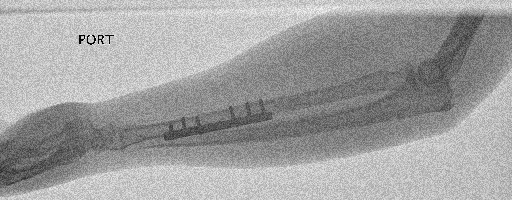

13.572553973417367 0.14766343951841332


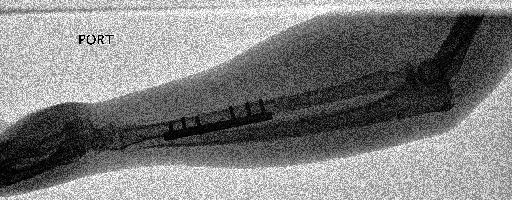

14.795926604809729 0.4260830364061906


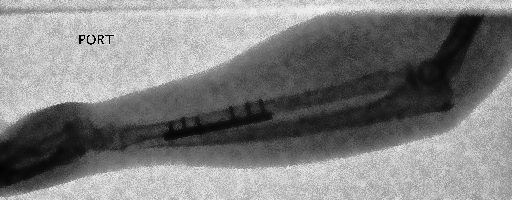

14.522466747682914 0.3309035150803432


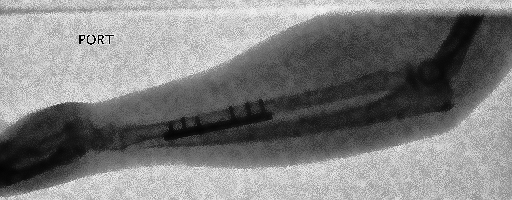

In [ ]:
img = cv2.imread('image5.png', 0)

img = img[0:200, 0:512] #Mantendo só a parte relevante cda imagem
# cv2_imshow(img)

img_ruido = add_noise(img, -25, 25)
psnr_val, ssim_val = calcular_metricas(img, img_ruido)
print(psnr_val, ssim_val)
cv2_imshow(img_ruido)

img_equalizada = histEqualization(img_ruido)
psnr_val, ssim_val = calcular_metricas(img, img_equalizada)
print(psnr_val, ssim_val)

cv2_imshow(img_equalizada)

# for k in [7, 9]: #TESTE DE VARIOS PARAMETROS
#     for sigma_esp in [ 1.5, 2.0, 3.0]:
#         for sigma_intens in [20, 30, 40, 50]:
#             img_suavizada = filtro_bilateralBW(img_equalizada, k, sigma_esp, sigma_intens)
#             psnr_val, ssim_val = calcular_metricas(img, img_suavizada)
#             print(k, sigma_esp, sigma_intens, ": ")
#             print(np.round(psnr_val,6), np.round(ssim_val,6))
            # cv2_imshow(img_suavizada)

# for k in [3, 5, 7, 9]:
#     img_suavizada = filtro_bilateralBW(filtro_mediana_otimizadoBW(img_equalizada, k), 7, 3.0, 50)
#     psnr_val, ssim_val = calcular_metricas(img, img_suavizada)
#     print(k, ": ")
#     print(np.round(psnr_val,6), np.round(ssim_val,6))
#     cv2_imshow(img_suavizada)

# img_suavizada = filtro_bilateralBW(img_equalizada, 9, 3.0, 50)
psnr_val, ssim_val = calcular_metricas(img, img_suavizada)
print(psnr_val, ssim_val)
cv2_imshow(img_suavizada)


# img_float = img_suavizada.astype(np.float64)
# laplaciano = obterLaplaciano(img_suavizada)
# for alpha in [0.01, 0.02, 0.03, 0.05, 0.075, 0.1]:
#     resultado = img_float - alpha * laplaciano
#     resultado = np.clip(resultado, 0, 255).astype(np.uint8)
#     psnr_val, ssim_val = calcular_metricas(img, resultado)
#     print(psnr_val, ssim_val)
#     cv2_imshow(resultado)

img_float = img_suavizada.astype(np.float64)
laplaciano = obterLaplaciano(img_suavizada)
alpha = 0.1
resultado = img_float - alpha * laplaciano
resultado = np.clip( resultado, 0, 255 ).astype(np.uint8)
psnr_val, ssim_val = calcular_metricas(img, resultado)
print(psnr_val, ssim_val)
cv2_imshow(resultado)


#Teste alterando o pipeline 1 (Suavização -> Sharpness ->Equalização)

Nesse teste manteremos o mesmo ruído, mas iremos realizar a equalização no final.
Ajustando os parametros de suavização e sharpness para tentar obeter resultados melhores aos anteriores.


[Ruído](https://drive.google.com/file/d/15WzQS2Ddfy49l5bmOzxWqFds4VKPovjz/view?usp=drive_link) de -25 até +25, com resultados:<br>
PSNR: 24.96925431134551 <br>
SSIM: 0.34769829008371156<br>

após o [Filtro bilateral](https://drive.google.com/file/d/1uP1irKp_qyd40d1ulB2zpR9txvu-l2T2/view?usp=drive_link) com os melhores parametros após testes(9, 2.0, 50),obtemos:<br>
PSNR: 35.57499303413566 <br>
SSIM: 0.8897689897974288 <br>
Que são resultados elevados comparados a imagem de ruído e ainda mais elevados ao comparar com o primeiro pipeline, onde a suavização estava tratando o ruído elevado pela equalização de histograma.

Em [Sharpness](https://drive.google.com/file/d/1GpYBbGNKPYiS9A9XjHfNyjE7Ty5Sqz6S/view?usp=drive_link), testando novamente com alphas diferentes:
```
img_float = img_suavizada.astype(np.float64)
laplaciano = obterLaplaciano(img_suavizada)
for alpha in [0.1, 0.2, 0.3, 0.5, 0.7]:
    resultado = img_float - alpha * laplaciano
    resultado = np.clip(resultado, 0, 255).astype(np.uint8)
    psnr_val, ssim_val = calcular_metricas(img, resultado)
    print(psnr_val, ssim_val)
#34.86574686806163 0.8739531924970513
#34.12262696952651 0.8524224765617242
#33.3073082039233 0.8261619157786254
#32.18439563329805 0.7649615235761763
#30.914287175400126 0.6975951384656326
```
Novamente obtemos resultados inferiores quando comparado a suavização, com as métricas diminuindo quando o alpha aumenta. Então selecionamos o alpha 0.1 e avançamos para a última etapa.

[Equalização](https://drive.google.com/file/d/12YIy5gH7QGxVgp_wx5RF0Xtkqtw3_tlp/view?usp=drive_link):
PSNR: 13.940486607919638 <br>
SSIM: 0.40450225914787247 <br>
Essas métricas são bem baixas, com a equalização fazendo uma alteração muito grande na distribuição de intensidades em relação à imagem original. Esses valores acabaram sendo inferiores as passo anterior, mas próximos ao pipeline anterior, com o SSIM melhor.
onde a Equalização de histograma como primeira etapa teve:
PSNR: 13.572553973417367
SSIM: 0.14766343951841332
e o resultado do Pipeline(Equalização -> Suavização -> Sharpness) foi:
PSNR: 14.522466747682914
SSIM: 0.3309035150803432


A equalização acaba fazendo sua função e introduzindo mais contraste no caso dessa imagem utilizada, mas acabou diminuindo muito as métricas utilizadas.

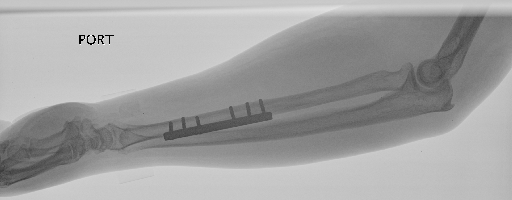

24.96925431134551 0.34769829008371156


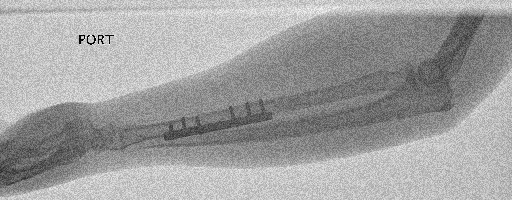

35.57499303413566 0.8897689897974288


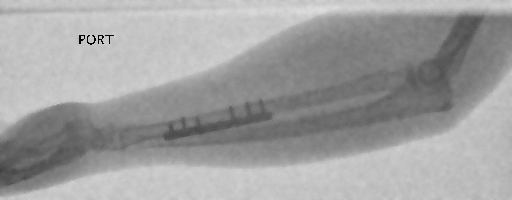

34.86574686806163 0.8739531924970513


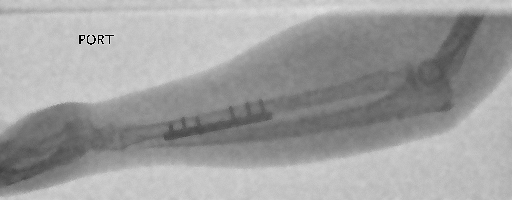

13.940486607919638 0.40450225914787247


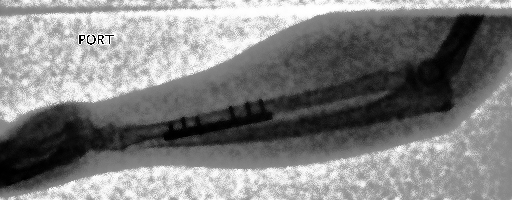

In [ ]:
img = cv2.imread('image5.png', 0)

img = img[0:200, 0:512] #Mantendo só a parte relevante cda imagem
cv2_imshow(img)

img_ruido = add_noise(img, -25, 25)
psnr_val, ssim_val = calcular_metricas(img, img_ruido)
print(psnr_val, ssim_val)
cv2_imshow(img_ruido)


# for k in [3, 5, 7, 9]: #TESTE DE VARIOS PARAMETROS
#     for sigma_esp in [ 1.5, 2.0, 3.0]:
#         for sigma_intens in [20, 30, 40, 50]:
#             img_suavizada = filtro_bilateralBW(img_ruido, k, sigma_esp, sigma_intens)
#             psnr_val, ssim_val = calcular_metricas(img, img_suavizada)
#             print(k, sigma_esp, sigma_intens, ": ")
#             print(np.round(psnr_val,6), np.round(ssim_val,6))
#             # cv2_imshow(img_suavizada)

# img_suavizada = filtro_bilateralBW(img_ruido, 9, 2.0, 50)
psnr_val, ssim_val = calcular_metricas(img, img_suavizada)
print(psnr_val, ssim_val)
cv2_imshow(img_suavizada)


# img_float = img_suavizada.astype(np.float64)
# laplaciano = obterLaplaciano(img_suavizada)
# for alpha in [0.01, 0.02, 0.03, 0.05, 0.075, 0.1]:
# # for alpha in [0.1, 0.2, 0.3, 0.5, 0.7]:
#     resultado = img_float - alpha * laplaciano
#     resultado = np.clip(resultado, 0, 255).astype(np.uint8)
#     psnr_val, ssim_val = calcular_metricas(img, resultado)
#     print(psnr_val, ssim_val)
#     cv2_imshow(resultado)

img_float = img_suavizada.astype(np.float64)
laplaciano = obterLaplaciano(img_suavizada)
alpha = 0.1
resultado = img_float - alpha * laplaciano
resultado = np.clip( resultado, 0, 255 ).astype(np.uint8)
psnr_val, ssim_val = calcular_metricas(img, resultado)
print(psnr_val, ssim_val)
cv2_imshow(resultado)


img_equalizada = histEqualization(resultado)
psnr_val, ssim_val = calcular_metricas(img, img_equalizada)
print(psnr_val, ssim_val)
cv2_imshow(img_equalizada)